# SIH26174 — Notebook 02: Preprocessing

**Project:** BAS Experiment Monitor (SIH26174) — AI Human Activity Recognition for On-board BAS Experiments
**Part:** Part 1 — Model Development (Training Pipeline)
**Stage:** Notebook 02 of the training pipeline

## 1. Objective and Scope

This notebook prepares a **reproducible dataset representation** of HMDB51 for action-recognition
training. It consumes the outputs of Notebook 01 rather than rediscovering the dataset from
scratch, and it produces the split metadata and preprocessing configuration that
`05_action_recognition_training.ipynb` will consume later.

Concretely, this notebook:

1. Mounts Google Drive and verifies the dataset root.
2. Loads the class mapping and dataset summary produced by **Notebook 01**.
3. Enumerates usable video files (excluding videos Notebook 01 flagged as unreadable, when known).
4. Creates a deterministic, video-level **train / validation / test split** with no data leakage.
5. Validates split integrity.
6. Defines a single, central **preprocessing configuration** (clip length, frame sampling, image
   size, normalization, augmentation).
7. Implements and validates a reusable **clip-sampling function** on a small number of sample
   videos only.
8. Saves the split CSVs and `dataset_config.yaml` for later notebooks.

### Explicit scope boundaries

This notebook does **NOT**:

- extract every frame from every video or create millions of image files,
- install, load, run, fine-tune, or evaluate YOLOv8 (that belongs to Notebook 03),
- fabricate object-detection or bounding-box annotations from HMDB51,
- invent SIH-specific laboratory action labels (e.g. `pick_beaker`, `pour_liquid`) — HMDB51 class
  names are used exactly as provided by Notebook 01's class mapping,
- train, fine-tune, or evaluate any action-recognition model,
- implement experiment-validation, state-machine, GUI, or voice-alert logic (Part 2 concerns).

The dataset directory (`hmdb51_sta/`) is treated as **read-only source data** throughout.


## 2. Imports

In [1]:
import os
import sys
import json
import random
import warnings
from pathlib import Path
from collections import defaultdict, OrderedDict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

try:
    import yaml
    HAVE_YAML = True
except ImportError:
    HAVE_YAML = False

try:
    import torch
    HAVE_TORCH = True
except ImportError:
    HAVE_TORCH = False

print("Python version:", sys.version.split()[0])
print("OpenCV version:", cv2.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("PyYAML available:", HAVE_YAML)
print("PyTorch available:", HAVE_TORCH)


Python version: 3.13.15
OpenCV version: 4.14.0
Pandas version: 2.2.3
NumPy version: 2.1.3
PyYAML available: True
PyTorch available: True


## 3. Configuration

Every path and every preprocessing/augmentation/split parameter lives in this one cell. Nothing
else in the notebook should hardcode a value that belongs here — Notebook 05 is expected to reuse
these exact parameters via `dataset_config.yaml`.

`DATASET_ROOT` is the only hardcoded absolute path in this notebook, matching Notebook 01.


In [2]:
# ---------------------------------------------------------------------------
# Dataset location (the single hardcoded absolute path allowed in this notebook)
# ---------------------------------------------------------------------------
DATASET_ROOT = Path(
    "/content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta"
)

# ---------------------------------------------------------------------------
# Project paths, derived from DATASET_ROOT (same convention as Notebook 01)
# DATASET_ROOT = <TRAINING_ROOT>/data/raw/hmdb51_sta  =>  TRAINING_ROOT = DATASET_ROOT.parents[2]
# ---------------------------------------------------------------------------
TRAINING_ROOT = DATASET_ROOT.parents[2]
CONFIGS_DIR = TRAINING_ROOT / "configs"
REPORTS_DIR = TRAINING_ROOT / "reports"
SPLITS_DIR = TRAINING_ROOT / "data" / "splits"

# Notebook 01 artifacts (inputs to this notebook)
CLASS_MAPPING_PATH = CONFIGS_DIR / "action_classes.json"
DATASET_SUMMARY_JSON_PATH = REPORTS_DIR / "dataset_summary.json"

# This notebook's outputs
TRAIN_SPLIT_PATH = SPLITS_DIR / "train.csv"
VAL_SPLIT_PATH = SPLITS_DIR / "val.csv"
TEST_SPLIT_PATH = SPLITS_DIR / "test.csv"
DATASET_CONFIG_PATH = CONFIGS_DIR / "dataset_config.yaml"

# ---------------------------------------------------------------------------
# Video file discovery (must match Notebook 01's convention)
# ---------------------------------------------------------------------------
SUPPORTED_VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv", ".webm"}

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
RANDOM_SEED = 42

# ---------------------------------------------------------------------------
# Split configuration
# ---------------------------------------------------------------------------
# Starting ratios per the project spec. Kept configurable rather than buried in
# logic. Splitting is stratified per class and always operates at the VIDEO
# level (never frame-level) to avoid data leakage between splits.
SPLIT_RATIOS = OrderedDict([
    ("train", 0.70),
    ("val", 0.15),
    ("test", 0.15),
])
assert abs(sum(SPLIT_RATIOS.values()) - 1.0) < 1e-6, "Split ratios must sum to 1.0"

# ---------------------------------------------------------------------------
# Preprocessing configuration (central — reused by Notebook 05)
# ---------------------------------------------------------------------------
CLIP_LENGTH = 16                    # number of frames sampled per clip
FRAME_SAMPLING_STRATEGY = "uniform_linspace_with_repetition"
# ============================================================================
# TARGET ACTIONS FOR SPLITTING
# ============================================================================
# All 6 actions to include in train/val/test splits.
# Split ratios will be applied per-action to maintain class distribution.

TARGET_ACTIONS = [
    "catch",      # Positive class for binary classification
    "clap",       # Negative classes (HMDB51 source)
    "drink",
    "eat",
    "jump",
    "throw",
]

print(f"Target actions: {TARGET_ACTIONS}")

# Map actions to indices (for reference only — splits preserve action names)
ACTION_INDEX_MAP = {action: idx for idx, action in enumerate(sorted(TARGET_ACTIONS))}
print(f"Action index map: {ACTION_INDEX_MAP}")

# Update dataset config path to JSON format
DATASET_CONFIG_PATH = CONFIGS_DIR / "dataset_config.json"
# Strategy detail: frame indices are chosen with np.linspace(0, frame_count-1,
# num=CLIP_LENGTH), rounded to the nearest integer index. For videos with
# fewer frames than CLIP_LENGTH, linspace naturally repeats indices, which is
# the documented strategy for handling short videos (rather than padding with
# blank frames or discarding the video).
IMAGE_SIZE = 224                    # square resize target (H == W == IMAGE_SIZE)

# Normalization (ImageNet statistics — a common, reasonable default for
# pretrained video/image backbones; Notebook 05 may override if the chosen
# backbone documents different statistics).
NORMALIZATION_MEAN = [0.485, 0.456, 0.406]
NORMALIZATION_STD = [0.229, 0.224, 0.225]

# ---------------------------------------------------------------------------
# Output tensor layout (documented explicitly, no silent assumptions)
# ---------------------------------------------------------------------------
TENSOR_LAYOUT = "[T, C, H, W]"  # T=CLIP_LENGTH, C=3 (RGB), H=W=IMAGE_SIZE

# ---------------------------------------------------------------------------
# Augmentation configuration — TRAIN split only. Validation/test preprocessing
# is always deterministic (no randomness).
# ---------------------------------------------------------------------------
TRAIN_AUGMENTATION_CONFIG = {
    "horizontal_flip_prob": 0.5,     # same flip decision applied to every frame in a clip
    "brightness_jitter_range": [-0.05, 0.05],  # additive, same shift applied to every frame
}

# ---------------------------------------------------------------------------
# Validation-of-this-notebook settings (kept tiny and fast — NOT full dataset
# preprocessing)
# ---------------------------------------------------------------------------
NUM_SAMPLE_VIDEOS_PER_SPLIT_FOR_CLIP_CHECK = 2

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("DATASET_ROOT      :", DATASET_ROOT)
print("TRAINING_ROOT       :", TRAINING_ROOT)
print("SPLITS_DIR            :", SPLITS_DIR)
print("CLASS_MAPPING_PATH      :", CLASS_MAPPING_PATH)
print("DATASET_SUMMARY_JSON_PATH:", DATASET_SUMMARY_JSON_PATH)
print("DATASET_CONFIG_PATH       :", DATASET_CONFIG_PATH)
print("Split ratios:", dict(SPLIT_RATIOS))
print(f"clip_length={CLIP_LENGTH}, image_size={IMAGE_SIZE}, tensor_layout={TENSOR_LAYOUT}")


Target actions: ['catch', 'clap', 'drink', 'eat', 'jump', 'throw']
Action index map: {'catch': 0, 'clap': 1, 'drink': 2, 'eat': 3, 'jump': 4, 'throw': 5}
DATASET_ROOT      : /content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta
TRAINING_ROOT       : /content/drive/MyDrive/SIH26174/training
SPLITS_DIR            : /content/drive/MyDrive/SIH26174/training/data/splits
CLASS_MAPPING_PATH      : /content/drive/MyDrive/SIH26174/training/configs/action_classes.json
DATASET_SUMMARY_JSON_PATH: /content/drive/MyDrive/SIH26174/training/reports/dataset_summary.json
DATASET_CONFIG_PATH       : /content/drive/MyDrive/SIH26174/training/configs/dataset_config.json
Split ratios: {'train': 0.7, 'val': 0.15, 'test': 0.15}
clip_length=16, image_size=224, tensor_layout=[T, C, H, W]


## 4. Mount Google Drive

Mounts Drive when running in Colab. Falls back gracefully (with a warning) when run outside Colab,
as long as `DATASET_ROOT` is reachable some other way.


In [3]:
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print(
        "Not running inside Google Colab — skipping drive.mount(). "
        "Make sure DATASET_ROOT is reachable on this filesystem."
    )


Mounted at /content/drive


## 5. Verify Paths

Confirm the dataset root and the Notebook 01 output directory exist before doing anything else.


In [4]:
import sys
from pathlib import Path

# Auto-mount Google Drive if running inside Google Colab environment
if "google.colab" in sys.modules and not Path("/content/drive").exists():
    from google.colab import drive

    print("Mounting Google Drive...")
    drive.mount("/content/drive")


def verify_path_exists(
    path: Path, description: str, must_be_dir: bool = True
) -> None:
    """Verifies that a required path exists on disk with actionable diagnostic output."""
    path = Path(path)
    if not path.exists():
        parent = path.parent
        parent_contents = (
            [p.name for p in parent.iterdir()] if parent.exists() else []
        )
        raise FileNotFoundError(
            f"{description} does not exist:\n  {path}\n\n"
            f"Diagnostic Info:\n"
            f"  - Parent folder exists: {parent.exists()} ({parent})\n"
            f"  - Items found in parent: {parent_contents if parent_contents else 'None / Parent Missing'}\n"
            f"  - Hint: Check if Drive is mounted or if folder name was truncated (e.g. 'hmdb51_sta')."
        )
    if must_be_dir and not path.is_dir():
        raise NotADirectoryError(f"{description} is not a directory:\n  {path}")


# Execute path verifications
verify_path_exists(DATASET_ROOT, "Dataset root")
print("✓ Dataset root OK:", DATASET_ROOT)

if not CLASS_MAPPING_PATH.exists():
    raise FileNotFoundError(
        f"Expected Notebook 01 output not found:\n  {CLASS_MAPPING_PATH}\n"
        "Please run '01_dataset_inspection.ipynb' first to generate the class mapping."
    )
print("✓ Class mapping file found:", CLASS_MAPPING_PATH)

if DATASET_SUMMARY_JSON_PATH.exists():
    print("✓ Dataset summary file found:", DATASET_SUMMARY_JSON_PATH)
else:
    print(
        "⚠️ WARNING: dataset_summary.json from Notebook 01 was not found. "
        "Continuing without it — unreadable-video exclusion will be skipped."
    )

✓ Dataset root OK: /content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta
✓ Class mapping file found: /content/drive/MyDrive/SIH26174/training/configs/action_classes.json
✓ Dataset summary file found: /content/drive/MyDrive/SIH26174/training/reports/dataset_summary.json


## 6. Load Notebook 01 Artifacts

Load the class mapping (`action_classes.json`) and, when available, the dataset summary
(`dataset_summary.json`). Class IDs are **not** regenerated here — they are used exactly as
produced by Notebook 01 so that all notebooks share one label space.


In [5]:
with open(CLASS_MAPPING_PATH, "r") as f:
    id_to_class = json.load(f)  # {"0": "brush_hair", "1": "cartwheel", ...}

# Build the inverse mapping. Keys in the JSON file are strings; convert to int IDs.
class_to_id = {name: int(cid) for cid, name in id_to_class.items()}
sorted_class_names = sorted(class_to_id.keys())

print(f"Loaded {len(class_to_id)} classes from: {CLASS_MAPPING_PATH}")
print("First 5 classes:", sorted_class_names[:5])


Loaded 51 classes from: /content/drive/MyDrive/SIH26174/training/configs/action_classes.json
First 5 classes: ['brush_hair', 'cartwheel', 'catch', 'chew', 'clap']


In [6]:
dataset_summary = None
unreadable_rel_keys = set()

if DATASET_SUMMARY_JSON_PATH.exists():
    with open(DATASET_SUMMARY_JSON_PATH, "r") as f:
        dataset_summary = json.load(f)

    unreadable_entries = dataset_summary.get("unreadable_videos", [])
    for entry in unreadable_entries:
        # entry["path"] was an absolute path when Notebook 01 ran; reconstruct
        # a portable "<class_name>/<filename>" key so it still matches even if
        # the absolute mount path differs between runs.
        p = Path(entry["path"])
        rel_key = f"{p.parent.name}/{p.name}"
        unreadable_rel_keys.add(rel_key)

    print(f"Loaded dataset summary. Previously flagged unreadable videos: {len(unreadable_rel_keys)}")
else:
    print("No dataset summary loaded — unreadable-video exclusion is skipped (informational only).")


Loaded dataset summary. Previously flagged unreadable videos: 0


## 7. Enumerate Usable Videos

Walk each class folder named in the loaded class mapping, collect its video files, and associate
every video with `video_path` (stored **relative to `DATASET_ROOT`** for portability),
`class_name`, and `class_id`.

Videos that Notebook 01 previously flagged as unreadable are excluded here (when a dataset summary
was available), so the split does not include known-broken files.


In [7]:
from pathlib import Path

# Ensure DATASET_ROOT is a Path object
DATASET_ROOT = Path(DATASET_ROOT)

# Normalize extensions so they always include leading dots and lowercase
SUPPORTED_EXTS = {
    ext.lower() if ext.startswith(".") else f".{ext.lower()}"
    for ext in SUPPORTED_VIDEO_EXTENSIONS
}

# Convert unreadable keys to a set for O(1) fast lookup
unreadable_set = set(unreadable_rel_keys)


def find_video_files(class_dir: Path):
    """Return sorted list of video files matching SUPPORTED_VIDEO_EXTENSIONS in a class directory."""
    if not class_dir.is_dir():
        return []
    return sorted(
        p
        for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS
    )


video_records = []
missing_class_dirs = []
excluded_unreadable_count = 0

for class_name in sorted_class_names:
    class_dir = DATASET_ROOT / class_name
    if not class_dir.is_dir():
        missing_class_dirs.append(class_name)
        continue

    class_id = class_to_id[class_name]
    for video_path in find_video_files(class_dir):
        # Generate OS-independent POSIX path relative to DATASET_ROOT
        rel_key = video_path.relative_to(DATASET_ROOT).as_posix()

        if rel_key in unreadable_set:
            excluded_unreadable_count += 1
            continue

        video_records.append(
            {
                "video_path": rel_key,  # relative to DATASET_ROOT (POSIX format)
                "class_name": class_name,
                "class_id": class_id,
            }
        )

print(f"Usable videos enumerated: {len(video_records)}")
print(f"Excluded (previously flagged unreadable): {excluded_unreadable_count}")
if missing_class_dirs:
    print(
        f"WARNING: {len(missing_class_dirs)} classes from the mapping have no folder on disk:"
    )
    print(" ", missing_class_dirs)
else:
    print("All mapped classes have a corresponding folder on disk.")

Usable videos enumerated: 6766
Excluded (previously flagged unreadable): 0
All mapped classes have a corresponding folder on disk.


## 8. Create Reproducible Train / Validation / Test Splits

The split is performed **per class** (stratified) and **at the video level** — never at the frame
level — using a fixed random seed. Every video belongs to exactly one split.


In [8]:
import random
from collections import defaultdict
from typing import Any, Dict, List, Mapping


def create_splits(
    records: List[Dict[str, Any]], ratios: Mapping[str, float], seed: int
) -> Dict[str, List[Dict[str, Any]]]:
    """Stratified, video-level, deterministic split using the Largest Remainder method.

    records: list of dicts with at least 'class_name'
    ratios: dict/OrderedDict like {'train': 0.7, 'val': 0.15, 'test': 0.15}
    seed: fixed random seed for reproducibility

    Returns: dict[str, list[dict]] keyed by split name, with a 'split' field
    added.
    """
    # Guard check: Ensure ratio percentages sum up to 1.0
    total_ratio = sum(ratios.values())
    if not (0.999 <= total_ratio <= 1.001):
        raise ValueError(
            f"Split ratios must sum to 1.0, got {total_ratio:.4f}"
        )

    rng = random.Random(seed)

    by_class = defaultdict(list)
    for rec in records:
        by_class[rec["class_name"]].append(rec)

    split_names = list(ratios.keys())
    result = {name: [] for name in split_names}
    small_classes = []

    for class_name in sorted(by_class.keys()):
        class_records = by_class[class_name][:]
        rng.shuffle(class_records)  # Deterministic shuffle per class
        n = len(class_records)

        if n < len(split_names):
            small_classes.append((class_name, n))

        # Compute integer counts per split
        raw_counts = {name: n * ratio for name, ratio in ratios.items()}
        floor_counts = {name: int(raw_counts[name]) for name in split_names}
        remainder = n - sum(floor_counts.values())

        # Distribute remaining items based on largest fractional part
        fractional = sorted(
            split_names,
            key=lambda name: raw_counts[name] - floor_counts[name],
            reverse=True,
        )
        for i in range(remainder):
            floor_counts[fractional[i % len(split_names)]] += 1

        cursor = 0
        for name in split_names:
            count = floor_counts[name]
            chunk = class_records[cursor : cursor + count]
            for rec in chunk:
                # Modern dictionary merge (preserves original rec, adds split field)
                rec_with_split = {**rec, "split": name}
                result[name].append(rec_with_split)
            cursor += count

    if small_classes:
        print(
            f"NOTE: {len(small_classes)} class(es) have fewer videos than there are splits ({len(split_names)}), "
            "so at least one split will receive zero videos for those classes:"
        )
        for name, count in small_classes:
            print(f"  - {name}: {count} video(s)")

    return result


# Execute split generation
splits = create_splits(video_records, SPLIT_RATIOS, RANDOM_SEED)

# Print verification statistics
total_usable = len(video_records)
print("\n--- Split Breakdown ---")
for name in SPLIT_RATIOS.keys():
    split_count = len(splits[name])
    pct = (split_count / total_usable) * 100 if total_usable > 0 else 0
    print(f"{name:5s}: {split_count:5d} videos ({pct:5.1f}%)")

total_split_videos = sum(len(v) for v in splits.values())
print(f"\nTotal output videos : {total_split_videos}")
print(f"Total source videos : {total_usable}")

# Assert zero video leakage or loss
assert (
    total_split_videos == total_usable
), f"Data mismatch! {total_usable - total_split_videos} videos were lost during splitting."


--- Split Breakdown ---
train:  4738 videos ( 70.0%)
val  :  1023 videos ( 15.1%)
test :  1005 videos ( 14.9%)

Total output videos : 6766
Total source videos : 6766


## 9. Validate Split Integrity

Sanity-check the splits before saving anything:

- every listed video path actually exists on disk,
- every record's class exists in `action_classes.json`,
- no video path appears in more than one split (no leakage),
- split sizes are non-trivial and roughly match the configured ratios.


In [9]:
from pathlib import Path
from typing import Any, Dict, List


def validate_splits(
    splits: Dict[str, List[Dict[str, Any]]],
    dataset_root: Path,
    class_to_id: Dict[str, int],
) -> List[str]:
    """Validates split integrity: filesystem existence, ID consistency, duplicate records,

    and cross-split data leakage.
    """
    dataset_root = Path(dataset_root)
    errors = []

    all_paths_by_split: Dict[str, set] = {}
    seen_paths = set()
    duplicate_paths = set()

    for split_name, records in splits.items():
        paths_in_split = set()

        for rec in records:
            rel_path = rec["video_path"]
            abs_path = dataset_root / rel_path

            # 1. Verify split key consistency
            if rec.get("split") and rec["split"] != split_name:
                errors.append(
                    f"[{split_name}] Split label mismatch: record has '{rec['split']}'"
                )

            # 2. Check physical file existence on disk
            if not abs_path.is_file():
                errors.append(
                    f"[{split_name}] Missing file on disk: {abs_path}"
                )

            # 3. Check class mapping and class_id match
            class_name = rec.get("class_name")
            if class_name not in class_to_id:
                errors.append(
                    f"[{split_name}] Unknown class_name: '{class_name}'"
                )
            elif rec.get("class_id") != class_to_id[class_name]:
                errors.append(
                    f"[{split_name}] class_id mismatch for '{rel_path}': "
                    f"record has {rec.get('class_id')}, mapping has {class_to_id[class_name]}"
                )

            # 4. Track paths for duplicate detection
            if rel_path in seen_paths:
                duplicate_paths.add(rel_path)
            seen_paths.add(rel_path)
            paths_in_split.add(rel_path)

        all_paths_by_split[split_name] = paths_in_split

    # 5. Cross-split data leakage check
    split_names = list(all_paths_by_split.keys())
    for i in range(len(split_names)):
        for j in range(i + 1, len(split_names)):
            s1, s2 = split_names[i], split_names[j]
            overlap = all_paths_by_split[s1] & all_paths_by_split[s2]
            if overlap:
                errors.append(
                    f"Data Leakage: {len(overlap)} video(s) shared between '{s1}' and '{s2}'"
                )

    # 6. Global duplicate path check
    if duplicate_paths:
        errors.append(
            f"{len(duplicate_paths)} duplicate video_path entry/entries found overall"
        )

    return errors


# Run validation
validation_errors = validate_splits(splits, DATASET_ROOT, class_to_id)

if validation_errors:
    print(
        f"❌ Found {len(validation_errors)} split validation issue(s) (showing up to 20):"
    )
    for err in validation_errors[:20]:
        print(f"  - {err}")
    raise AssertionError(
        "Split validation failed. Fix the issues above before proceeding."
    )
else:
    print(
        "✓ Split validation passed: 0 missing files, 0 unknown classes, 0 data leakages, 0 duplicates."
    )

✓ Split validation passed: 0 missing files, 0 unknown classes, 0 data leakages, 0 duplicates.


## 10. Preprocessing Configuration (Recap)

The full preprocessing configuration was already centralized in **Section 3**
(`CLIP_LENGTH`, `FRAME_SAMPLING_STRATEGY`, `IMAGE_SIZE`, `NORMALIZATION_MEAN/STD`,
`TENSOR_LAYOUT`, `TRAIN_AUGMENTATION_CONFIG`). This section only displays it for clarity — it is
not redefined here, to keep a single source of truth.


In [10]:
import json

preprocessing_config_preview = {
    "clip_length": CLIP_LENGTH,
    "frame_sampling_strategy": FRAME_SAMPLING_STRATEGY,
    "image_size": IMAGE_SIZE,
    "tensor_layout": TENSOR_LAYOUT,
    "normalization": {"mean": NORMALIZATION_MEAN, "std": NORMALIZATION_STD},
    "train_augmentation": TRAIN_AUGMENTATION_CONFIG,
    "val_test_augmentation": "none (deterministic preprocessing only)",
}

print("--- Preprocessing Configuration ---")
for key, value in preprocessing_config_preview.items():
    if isinstance(value, dict):
        formatted_val = json.dumps(value, indent=2)
        # Indent nested dictionary output for visual readability
        formatted_val = formatted_val.replace("\n", "\n" + " " * 27)
        print(f"{key:25s}: {formatted_val}")
    else:
        print(f"{key:25s}: {value}")

--- Preprocessing Configuration ---
clip_length              : 16
frame_sampling_strategy  : uniform_linspace_with_repetition
image_size               : 224
tensor_layout            : [T, C, H, W]
normalization            : {
                             "mean": [
                               0.485,
                               0.456,
                               0.406
                             ],
                             "std": [
                               0.229,
                               0.224,
                               0.225
                             ]
                           }
train_augmentation       : {
                             "horizontal_flip_prob": 0.5,
                             "brightness_jitter_range": [
                               -0.05,
                               0.05
                             ]
                           }
val_test_augmentation    : none (deterministic preprocessing only)


## 11. Implement Clip Sampling

A reusable function that converts a video into a fixed-length clip tensor:

```
video -> temporal sampling (CLIP_LENGTH frames) -> resize to IMAGE_SIZE -> normalize -> tensor
```

**Tensor layout:** `[T, C, H, W]` with `T = CLIP_LENGTH`, `C = 3` (RGB), `H = W = IMAGE_SIZE`.

**Short-video strategy:** frame indices are chosen via `np.linspace(0, frame_count - 1,
num=CLIP_LENGTH)`, rounded to the nearest integer. When a video has fewer frames than
`CLIP_LENGTH`, `linspace` naturally selects some frame indices more than once — i.e. frames are
**repeated**, not padded with blank frames and not discarded. This is documented as
`FRAME_SAMPLING_STRATEGY = "uniform_linspace_with_repetition"`.

**Augmentation:** only applied when `augment=True` (training split). A single flip decision and a
single brightness shift are drawn per clip and applied identically to every frame, to preserve
temporal coherence within the clip. Validation/test calls always use `augment=False`.


In [11]:
import random
from pathlib import Path
from typing import List, Optional, Tuple
import cv2
import numpy as np


def _sample_frame_indices(frame_count: int, clip_length: int) -> List[int]:
    """Uniform temporal sampling with repetition for short videos."""
    if frame_count <= 0:
        return [0] * clip_length
    indices = np.linspace(0, frame_count - 1, num=clip_length)
    indices = np.clip(np.round(indices).astype(int), 0, frame_count - 1)
    return indices.tolist()


def _read_frames_at_indices(
    video_path: Path, indices: List[int]
) -> Optional[List[np.ndarray]]:
    """Read specific frame indices from a video, returning a list aligned with `indices`.

    Falls back to sequential reading (buffering all frames) if frame-count metadata
    is unreliable or random seeking fails (common with non-keyframe AVI containers).
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        return None

    frames = []
    seek_failed = False
    try:
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ok, frame = cap.read()
            if not ok or frame is None:
                seek_failed = True
                break
            frames.append(frame)
    finally:
        cap.release()

    if not seek_failed and len(frames) == len(indices):
        return frames

    # Fallback: Sequential read of the whole video, then index into buffer
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        return None

    buffered = []
    try:
        while True:
            ok, frame = cap.read()
            if not ok or frame is None:
                break
            buffered.append(frame)
    finally:
        cap.release()

    if not buffered:
        return None

    safe_indices = [
        min(i, len(buffered) - 1)
        for i in _sample_frame_indices(len(buffered), len(indices))
    ]
    return [buffered[i] for i in safe_indices]


def apply_train_augmentation(
    clip: np.ndarray, rng: random.Random
) -> np.ndarray:
    """Apply conservative, clip-consistent augmentation.

    clip shape: [T, C, H, W]
    """
    cfg = TRAIN_AUGMENTATION_CONFIG

    # Horizontal flip along width axis (W = axis 3)
    if rng.random() < cfg.get("horizontal_flip_prob", 0.0):
        clip = clip[:, :, :, ::-1].copy()

    # Brightness jitter shift
    if "brightness_jitter_range" in cfg:
        low, high = cfg["brightness_jitter_range"]
        if low != 0.0 or high != 0.0:
            brightness_shift = rng.uniform(low, high)
            clip = clip + brightness_shift

    return clip


def sample_clip(
    video_path: Path,
    clip_length: int = CLIP_LENGTH,
    image_size: int = IMAGE_SIZE,
    augment: bool = False,
    seed: Optional[int] = None,
) -> Tuple[Optional[np.ndarray], Optional[str]]:
    """Sample a fixed-length clip tensor from a video file.

    Returns:
        (clip, error):
            clip  -> np.ndarray of shape [T, C, H, W], dtype float32, normalized, or None on failure
            error -> None on success, otherwise a short error message
    """
    video_path = Path(video_path)
    if not video_path.is_file():
        return None, f"file not found: {video_path}"

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        return None, "could not open video"

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    indices = _sample_frame_indices(frame_count, clip_length)
    frames_bgr = _read_frames_at_indices(video_path, indices)

    if frames_bgr is None or len(frames_bgr) == 0:
        return None, "no frames could be read"

    # Pad (repeat last frame) if fewer frames were read than requested
    while len(frames_bgr) < clip_length:
        frames_bgr.append(frames_bgr[-1])

    processed = []
    for frame in frames_bgr[:clip_length]:
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(
            rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR
        )
        processed.append(resized)

    # Convert array to float32 and scale to range [0, 1]
    clip = np.stack(processed, axis=0).astype(np.float32) / 255.0  # [T, H, W, C]

    # Apply mean and std normalization across channels
    mean = np.array(NORMALIZATION_MEAN, dtype=np.float32)
    std = np.array(NORMALIZATION_STD, dtype=np.float32)
    clip = (clip - mean) / std

    # Reorder layout from [T, H, W, C] to PyTorch tensor format [T, C, H, W]
    clip = np.transpose(clip, (0, 3, 1, 2))

    if augment:
        rng = random.Random(seed)
        clip = apply_train_augmentation(clip, rng)

    # Ensure C-contiguous memory layout for fast PyTorch tensor conversion
    return np.ascontiguousarray(clip, dtype=np.float32), None

## 12. Validate Sample Clips / Tensors

Run `sample_clip` on a **small number of sample videos** (not the full dataset) drawn from each
split, and check:

- the video can be loaded,
- the resulting tensor has shape `[CLIP_LENGTH, 3, IMAGE_SIZE, IMAGE_SIZE]`,
- normalized values fall in a sane numeric range,
- (train only) augmentation runs without error.

This is a **lightweight validation pass**, not full preprocessing of the dataset.


In [12]:
import random
import pandas as pd

# Check PyTorch availability safely
try:
    import torch

    HAVE_TORCH = True
except ImportError:
    HAVE_TORCH = False


def pick_sample_records(records: list, n: int, seed: int) -> list:
    """Deterministically pick up to `n` sample records."""
    rng = random.Random(seed)
    if len(records) <= n:
        return records[:]
    return rng.sample(records, n)


clip_check_rows = []

for split_name, records in splits.items():
    sample_records = pick_sample_records(
        records,
        NUM_SAMPLE_VIDEOS_PER_SPLIT_FOR_CLIP_CHECK,
        RANDOM_SEED,
    )
    is_train = split_name == "train"

    for idx, rec in enumerate(sample_records):
        abs_path = DATASET_ROOT / rec["video_path"]

        # Derive a unique per-video seed so each train clip gets distinct random augmentations
        sample_seed = (RANDOM_SEED + idx * 1000) if is_train else None

        clip, error = sample_clip(abs_path, augment=is_train, seed=sample_seed)

        row = {
            "split": split_name,
            "video_path": rec["video_path"],
            "class_name": rec["class_name"],
            "loaded_ok": error is None,
            "error": error if error else "None",
            "shape": None,
            "dtype": None,
            "min": None,
            "max": None,
            "mean": None,
        }

        if HAVE_TORCH:
            row["torch_shape"] = None
            row["torch_dtype"] = None

        if clip is not None:
            row["shape"] = tuple(clip.shape)
            row["dtype"] = str(clip.dtype)
            row["min"] = round(float(clip.min()), 4)
            row["max"] = round(float(clip.max()), 4)
            row["mean"] = round(float(clip.mean()), 4)

            expected_shape = (CLIP_LENGTH, 3, IMAGE_SIZE, IMAGE_SIZE)
            assert clip.shape == expected_shape, (
                f"Unexpected clip shape for {rec['video_path']}: "
                f"got {clip.shape}, expected {expected_shape}"
            )

            if HAVE_TORCH:
                tensor = torch.from_numpy(clip)
                row["torch_shape"] = tuple(tensor.shape)
                row["torch_dtype"] = str(tensor.dtype)

        clip_check_rows.append(row)

# Construct verification DataFrame
clip_check_df = pd.DataFrame(clip_check_rows)

# Print summary metrics before displaying table
total_checked = len(clip_check_df)
successful_loads = int(clip_check_df["loaded_ok"].sum())
failed_loads = total_checked - successful_loads

print("--- Clip Sampling Sanity Check ---")
print(f"Total clips sampled across splits : {total_checked}")
print(f"Successfully loaded and verified   : {successful_loads}/{total_checked}")

if failed_loads > 0:
    print(f"⚠️ Failed loads detected           : {failed_loads}")
else:
    print("✓ All sampled clips processed successfully without shape/loading errors.")

# Render DataFrame display
clip_check_df

--- Clip Sampling Sanity Check ---
Total clips sampled across splits : 6
Successfully loaded and verified   : 6/6
✓ All sampled clips processed successfully without shape/loading errors.


,split,video_path,class_name,loaded_ok,error,shape,dtype,min,max,mean,torch_shape,torch_dtype
0,train,drink/AmericanGangster_drink_u_nm_np1_le_goo_4...,drink,True,None,"(16, 3, 224, 224)",float32,-2.1654,1.1031,-1.7597,"(16, 3, 224, 224)",torch.float32
1,train,catch/Torwarttraining_2_(_sterreich)_catch_f_c...,catch,True,None,"(16, 3, 224, 224)",float32,-2.1324,2.5907,-0.3102,"(16, 3, 224, 224)",torch.float32
2,val,shoot_bow/Shootingarecurve_shoot_bow_u_cm_np1_...,shoot_bow,True,None,"(16, 3, 224, 224)",float32,-2.1179,2.6400,-0.2761,"(16, 3, 224, 224)",torch.float32
3,val,climb_stairs/Fellowship_6_climb_stairs_f_nm_np...,climb_stairs,True,None,"(16, 3, 224, 224)",float32,-2.1179,1.0017,-1.7012,"(16, 3, 224, 224)",torch.float32
4,test,shoot_gun/GLOCK17_shoot_gun_f_nm_np1_fr_med_3.avi,shoot_gun,True,None,"(16, 3, 224, 224)",float32,-2.1179,2.5877,0.1804,"(16, 3, 224, 224)",torch.float32
5,test,climb_stairs/Piano_stairs__-_TheFunTheory_com_...,climb_stairs,True,None,"(16, 3, 224, 224)",float32,-2.1179,2.6400,-0.1500,"(16, 3, 224, 224)",torch.float32


In [13]:
# ==========================================
# CELL 13: Clip Validation Output Reporting
# ==========================================
num_failed = (
    int((~clip_check_df["loaded_ok"]).sum()) if not clip_check_df.empty else 0
)

if clip_check_df.empty:
    print(
        "⚠️ No sample videos were available to validate (splits appear to be empty)."
    )
elif num_failed > 0:
    print(
        f"❌ WARNING: {num_failed} sample video(s) failed to produce a clip during this lightweight validation pass:"
    )
    print(
        clip_check_df[~clip_check_df["loaded_ok"]][
            ["split", "video_path", "error"]
        ].to_string(index=False)
    )
else:
    ok_df = clip_check_df[clip_check_df["loaded_ok"]]
    print(
        f"✓ All {len(clip_check_df)} sampled clips loaded successfully with expected shape "
        f"[{CLIP_LENGTH}, 3, {IMAGE_SIZE}, {IMAGE_SIZE}]."
    )
    print(
        f"  Value range across valid samples: "
        f"min={ok_df['min'].min():.3f}, max={ok_df['max'].max():.3f}, mean={ok_df['mean'].mean():.3f}"
    )

✓ All 6 sampled clips loaded successfully with expected shape [16, 3, 224, 224].
  Value range across valid samples: min=-2.165, max=2.640, mean=-0.669


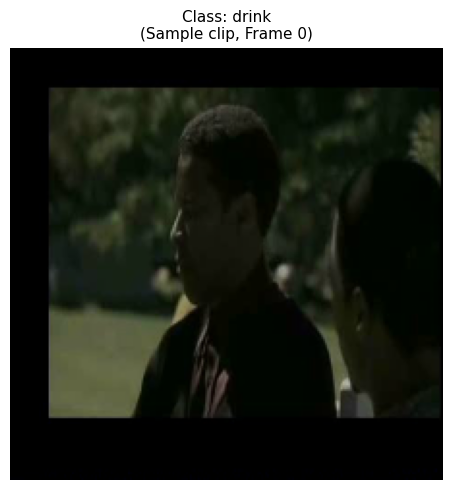

In [14]:
# ==========================================
# CELL 14: Visual Sanity Check (Frame 0)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# Find first successfully loaded train record
train_rows = [
    r for r in clip_check_rows if r["split"] == "train" and r["loaded_ok"]
]

if train_rows:
    sample_row = train_rows[0]
    abs_path = DATASET_ROOT / sample_row["video_path"]

    # Sample deterministically for display (augment=False)
    clip, clip_err = sample_clip(abs_path, augment=False)

    if clip is not None and clip_err is None:
        first_frame_chw = clip[0]  # Shape: [C, H, W], normalized

        # Denormalize clip for RGB display: (X * std) + mean
        mean = np.array(NORMALIZATION_MEAN, dtype=np.float32).reshape(3, 1, 1)
        std = np.array(NORMALIZATION_STD, dtype=np.float32).reshape(3, 1, 1)

        denorm = np.clip((first_frame_chw * std + mean), 0.0, 1.0)
        display_frame = np.transpose(denorm, (1, 2, 0))  # Shape: [H, W, C]

        plt.figure(figsize=(5, 5))
        plt.imshow(display_frame)
        plt.title(
            f"Class: {sample_row['class_name']}\n(Sample clip, Frame 0)",
            fontsize=11,
        )
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print(
            f"Failed to load frame for display from {abs_path}: {clip_err}"
        )
else:
    print("⚠️ No successfully loaded training sample available to visualize.")

## 13. Save Split CSV Files

Save `train.csv`, `val.csv`, and `test.csv` under `training/data/splits/`. Each row contains
`video_path` (relative to `DATASET_ROOT`), `class_name`, `class_id`, and `split`.


In [15]:
# ==========================================
# CELL 15: Save Split CSVs
# ==========================================
import pandas as pd

SPLITS_DIR.mkdir(parents=True, exist_ok=True)

split_path_map = {
    "train": TRAIN_SPLIT_PATH,
    "val": VAL_SPLIT_PATH,
    "test": TEST_SPLIT_PATH,
}

for split_name, out_path in split_path_map.items():
    records_list = splits.get(split_name, [])
    df = pd.DataFrame(
        records_list,
        columns=["video_path", "class_name", "class_id", "split"],
    )

    # Sort deterministically by class name and relative video path
    df = df.sort_values(["class_name", "video_path"]).reset_index(drop=True)
    df.to_csv(out_path, index=False, encoding="utf-8")

    print(f"✓ Saved {split_name:5s} split: {len(df):5d} rows -> {out_path}")

✓ Saved train split:  4738 rows -> /content/drive/MyDrive/SIH26174/training/data/splits/train.csv
✓ Saved val   split:  1023 rows -> /content/drive/MyDrive/SIH26174/training/data/splits/val.csv
✓ Saved test  split:  1005 rows -> /content/drive/MyDrive/SIH26174/training/data/splits/test.csv


## 14. Save `dataset_config.yaml`

Write a single machine-readable configuration file capturing everything a later notebook needs to
reproduce this dataset preparation: dataset identity, split file locations, random seed, class
mapping location, and the full preprocessing/augmentation configuration.

If `PyYAML` is unavailable in the current environment, the same content is written using `json`
instead — valid JSON is valid YAML, so the file remains a correctly parseable `.yaml` file either
way, and a warning is printed.


In [16]:
# ==========================================
# CELL 16: Save Dataset YAML/JSON Config
# ==========================================
import json
import warnings

# PyYAML check fallback
try:
    import yaml

    HAVE_YAML = True
except ImportError:
    HAVE_YAML = False

CONFIGS_DIR.mkdir(parents=True, exist_ok=True)

dataset_config = {
    "dataset": {
        "name": "HMDB51",
        "root": str(DATASET_ROOT),
        "class_mapping_path": str(CLASS_MAPPING_PATH),
        "num_classes": len(class_to_id),
    },
    "splits": {
        "train_csv": str(TRAIN_SPLIT_PATH),
        "val_csv": str(VAL_SPLIT_PATH),
        "test_csv": str(TEST_SPLIT_PATH),
        "ratios": dict(SPLIT_RATIOS),
        "random_seed": RANDOM_SEED,
        "num_train_videos": len(splits.get("train", [])),
        "num_val_videos": len(splits.get("val", [])),
        "num_test_videos": len(splits.get("test", [])),
    },
    "preprocessing": {
        "clip_length": CLIP_LENGTH,
        "frame_sampling_strategy": FRAME_SAMPLING_STRATEGY,
        "image_size": IMAGE_SIZE,
        "tensor_layout": TENSOR_LAYOUT,
        "normalization": {
            "mean": NORMALIZATION_MEAN,
            "std": NORMALIZATION_STD,
        },
    },
    "augmentation": {
        "train": TRAIN_AUGMENTATION_CONFIG,
        "val_test": "none (deterministic preprocessing only)",
    },
    "generated_by": "training/notebooks/02_preprocessing.ipynb",
}

if HAVE_YAML:
    with open(DATASET_CONFIG_PATH, "w", encoding="utf-8") as f:
        yaml.safe_dump(
            dataset_config, f, sort_keys=False, default_flow_style=False
        )
    print(
        f"✓ Saved dataset_config.yaml (PyYAML formatted) -> {DATASET_CONFIG_PATH}"
    )
else:
    warnings.warn(
        "PyYAML is not installed. Writing dataset_config.yaml in JSON formatting fallback."
    )
    with open(DATASET_CONFIG_PATH, "w", encoding="utf-8") as f:
        json.dump(dataset_config, f, indent=2)
    print(
        f"✓ Saved dataset_config.yaml (JSON fallback) -> {DATASET_CONFIG_PATH}"
    )

✓ Saved dataset_config.yaml (PyYAML formatted) -> /content/drive/MyDrive/SIH26174/training/configs/dataset_config.json


## 15. Final Summary

Consolidated confirmation of everything this notebook produced, and the exact parameters Notebook
05 should reuse.


In [17]:
# ==========================================
# CELL 17: Preprocessing Notebook Summary
# ==========================================
print("=" * 70)
print("NOTEBOOK 02 — PREPROCESSING — FINAL SUMMARY")
print("=" * 70)
print(f"Dataset root            : {DATASET_ROOT}")
print(f"Number of classes       : {len(class_to_id)}")
print(f"Total usable videos     : {len(video_records)}")
print(f"  - Training videos     : {len(splits.get('train', []))}")
print(f"  - Validation videos   : {len(splits.get('val', []))}")
print(f"  - Test videos         : {len(splits.get('test', []))}")
print(f"Split ratios            : {dict(SPLIT_RATIOS)}")
print(f"Random seed             : {RANDOM_SEED}")
print(f"Clip length             : {CLIP_LENGTH} frames")
print(f"Image size              : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Frame sampling strategy : {FRAME_SAMPLING_STRATEGY}")
print(f"Tensor layout           : {TENSOR_LAYOUT}")
print("-" * 70)
print("Generated files:")
print(f"  - Train CSV           : {TRAIN_SPLIT_PATH}")
print(f"  - Val CSV             : {VAL_SPLIT_PATH}")
print(f"  - Test CSV            : {TEST_SPLIT_PATH}")
print(f"  - Config YAML         : {DATASET_CONFIG_PATH}")
print("=" * 70)
print("📌 NOTE: Preprocessing was validated on a lightweight sample.")
print("   Full dataset clip extraction is performed dynamically on-the-fly")
print("   during PyTorch DataLoader iteration in training.")

NOTEBOOK 02 — PREPROCESSING — FINAL SUMMARY
Dataset root            : /content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta
Number of classes       : 51
Total usable videos     : 6766
  - Training videos     : 4738
  - Validation videos   : 1023
  - Test videos         : 1005
Split ratios            : {'train': 0.7, 'val': 0.15, 'test': 0.15}
Random seed             : 42
Clip length             : 16 frames
Image size              : 224x224
Frame sampling strategy : uniform_linspace_with_repetition
Tensor layout           : [T, C, H, W]
----------------------------------------------------------------------
Generated files:
  - Train CSV           : /content/drive/MyDrive/SIH26174/training/data/splits/train.csv
  - Val CSV             : /content/drive/MyDrive/SIH26174/training/data/splits/val.csv
  - Test CSV            : /content/drive/MyDrive/SIH26174/training/data/splits/test.csv
  - Config YAML         : /content/drive/MyDrive/SIH26174/training/configs/dataset_config.json
📌 NO